In [1]:
import os

print(os.listdir('/kaggle/input'))

['competitions']


In [2]:
import os

base_path = "/kaggle/input"

print(os.listdir("/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak"))

['EuroSAT', 'eye_diseases_classification', 'cassava_leaf_disease_classification', 'synthetic_industrial_metal_surface_defects']


In [3]:
import os

eurosat_path = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT"

print(os.listdir(eurosat_path))

['EuroSATallBands', 'EuroSAT']


In [4]:
rgb_path = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT"

print(os.listdir(rgb_path))

['SeaLake', 'Highway', 'River', 'Pasture', 'Industrial', 'Residential', 'PermanentCrop', 'validation.csv', 'AnnualCrop', 'train.csv', 'test.csv', 'label_map.json', 'Forest', 'HerbaceousVegetation']


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset path
dataset_path = "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT"

# Image preprocessing + augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Validation data
val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# Print class labels
print(train_data.class_indices)

2026-04-29 05:32:07.117388: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777440727.144353     441 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777440727.153262     441 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777440727.179769     441 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777440727.179792     441 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777440727.179795     441 computation_placer.cc:177] computation placer alr

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build final model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()

I0000 00:00:1777440743.502754     441 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777440743.507973     441 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1777440750.484318     518 service.cc:152] XLA service 0x79cd1c111130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777440750.484364     518 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777440750.484387     518 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777440751.496837     518 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-29 05:32:40.014041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:32:40.169142: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:32:40.305170: E external/local_xl

675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.6916 - loss: 0.8925

2026-04-29 05:37:57.710380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-29 05:37:57.846534: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


675/675 ━━━━━━━━━━━━━━━━━━━━ 335s 470ms/step - accuracy: 0.6918 - loss: 0.8921 - val_accuracy: 0.8585 - val_loss: 0.4136
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 311s 460ms/step - accuracy: 0.8480 - loss: 0.4371 - val_accuracy: 0.8620 - val_loss: 0.3820
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 298s 442ms/step - accuracy: 0.8557 - loss: 0.4061 - val_accuracy: 0.8891 - val_loss: 0.3352
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 304s 450ms/step - accuracy: 0.8689 - loss: 0.3851 - val_accuracy: 0.8937 - val_loss: 0.3080
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 300s 445ms/step - accuracy: 0.8681 - loss: 0.3801 - val_accuracy: 0.8891 - val_loss: 0.3212


In [8]:
model.save("eurosat_model.keras")

In [9]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)

169/169 ━━━━━━━━━━━━━━━━━━━━ 60s 357ms/step - accuracy: 0.8901 - loss: 0.3249
Validation Accuracy: 0.8907407522201538


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Image: /kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/Forest/Forest_1.jpg
Predicted Class: HerbaceousVegetation
Confidence: 64.15%
--------------------------------------------------


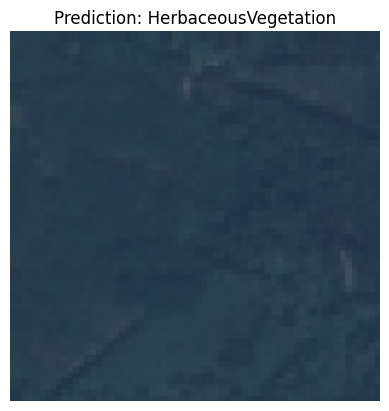

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Image: /kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/River/River_15.jpg
Predicted Class: River
Confidence: 83.86%
--------------------------------------------------


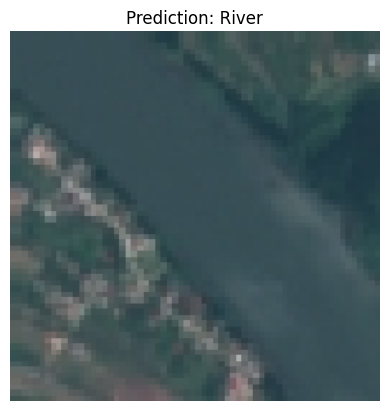

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

Image: /kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/SeaLake/SeaLake_8.jpg
Predicted Class: SeaLake
Confidence: 99.96%
--------------------------------------------------


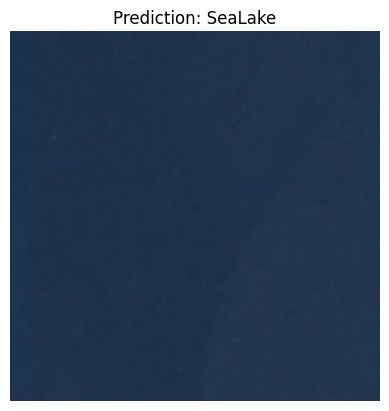

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Image: /kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/Residential/Residential_10.jpg
Predicted Class: Residential
Confidence: 100.00%
--------------------------------------------------


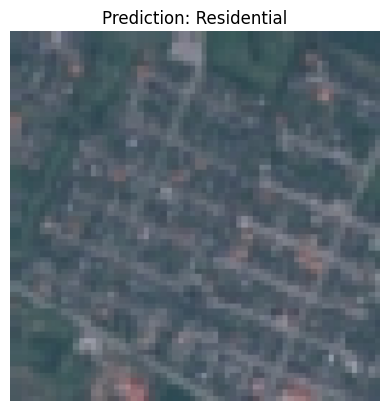

In [14]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# Test image paths
test_images = [
    "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/Forest/Forest_1.jpg",

    "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/River/River_15.jpg",

    "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/SeaLake/SeaLake_8.jpg",

    "/kaggle/input/competitions/kaggle-hac-x-26-data-sprint-to-the-peak/EuroSAT/EuroSAT/Residential/Residential_10.jpg"
]

# Class names
class_names = list(train_data.class_indices.keys())

for img_path in test_images:

    # Load image
    img = image.load_img(img_path, target_size=(224,224))

    # Convert to array
    img_array = image.img_to_array(img)

    # Expand dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # IMPORTANT preprocessing step
    img_array = preprocess_input(img_array)

    # Prediction
    prediction = model.predict(img_array)

    # Predicted class
    predicted_class = class_names[np.argmax(prediction)]

    # Confidence
    confidence = np.max(prediction) * 100

    # Print result
    print(f"\nImage: {img_path}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print("-"*50)

    # Display image
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}")
    plt.axis("off")
    plt.show()

In [16]:
model.save_weights("eurosat_weights.weights.h5")

In [18]:
app_code = '''
import streamlit as st
import numpy as np
from PIL import Image

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Build model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# Load weights
model.load_weights("eurosat_weights.weights.h5")

# Classes
class_names = [
    'AnnualCrop',
    'Forest',
    'HerbaceousVegetation',
    'Highway',
    'Industrial',
    'Pasture',
    'PermanentCrop',
    'Residential',
    'River',
    'SeaLake'
]

# Streamlit UI
st.title("EuroSAT Land Classification App")

uploaded_file = st.file_uploader(
    "Upload Image",
    type=["jpg","jpeg","png"]
)

if uploaded_file is not None:

    img = Image.open(uploaded_file)

    st.image(img, caption="Uploaded Image", use_container_width=True)

    img = img.resize((224,224))

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)

    predicted_class = class_names[np.argmax(prediction)]

    confidence = np.max(prediction) * 100

    st.success(f"Prediction: {predicted_class}")

    st.info(f"Confidence: {confidence:.2f}%")
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("NEW app.py created!")

NEW app.py created!
